# 📊 Healthcare Risk Analysis (EDA)

---

### **Objective:**
Analyze patient health and lifestyle data to identify key risk factors associated with chronic diseases, explore relationships between variables, and support data-driven healthcare insights.

### **Objective (Thai):**
วิเคราะห์ข้อมูลสุขภาพและพฤติกรรมของผู้ป่วย เพื่อค้นหาปัจจัยเสี่ยงที่สำคัญของโรคเรื้อรัง ศึกษาความสัมพันธ์ระหว่างตัวแปรต่าง ๆ และสนับสนุนการตัดสินใจด้านสุขภาพด้วยข้อมูล

---

## 🧩 1) Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 2) Load Dataset

In [2]:
file_path = r"S:\HealthcareProject\Dataset\Health_risk.csv"
df = pd.read_csv(file_path)

df.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


## 🔍 3) Data Understanding

### Data Preview
The dataset contains patient-level information including demographic, lifestyle, and clinical variables such as age, BMI, blood pressure, and disease status.

### คำอธิบาย
ชุดข้อมูลนี้ประกอบด้วยข้อมูลผู้ป่วย เช่น อายุ BMI ความดันโลหิต และสถานะของโรค ซึ่งจะใช้ในการวิเคราะห์ความเสี่ยงของโรค

In [3]:
df.columns

Index(['Age', 'Gender', 'Medical Condition', 'Glucose', 'Blood Pressure',
       'BMI', 'Oxygen Saturation', 'LengthOfStay', 'Cholesterol',
       'Triglycerides', 'HbA1c', 'Smoking', 'Alcohol', 'Physical Activity',
       'Diet Score', 'Family History', 'Stress Level', 'Sleep Hours',
       'random_notes', 'noise_col'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [5]:
df.describe()

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,noise_col
count,25500.000000,25500.000000,25500.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,54.616784,123.622179,140.455337,28.476155,94.954992,4.414133,213.033891,176.837375,6.294377,0.279767,0.238533,3.803214,4.029654,0.439433,5.917312,6.229836,-0.517010
std,15.973618,41.576943,21.077933,5.728804,3.736202,2.761536,33.519757,48.812827,1.320269,0.448892,0.426194,2.011729,1.817165,0.496326,2.225057,1.187669,100.076959
min,10.000000,20.320000,74.240000,7.670000,67.510000,1.000000,95.730000,-22.480000,3.280000,0.000000,0.000000,-3.680000,-1.750000,0.000000,-2.440000,1.590000,-412.169596
25%,45.000000,96.280000,125.140000,24.590000,93.000000,3.000000,189.500000,141.280000,5.330000,0.000000,0.000000,2.350000,2.770000,0.000000,4.370000,5.410000,-68.270749
50%,55.000000,110.500000,138.320000,28.050000,95.300000,4.000000,211.835000,173.365000,5.970000,0.000000,0.000000,3.590000,3.790000,0.000000,5.900000,6.230000,-0.510742
75%,66.000000,136.610000,153.790000,31.810000,97.380000,5.000000,235.310000,208.630000,6.920000,1.000000,0.000000,5.060000,5.020000,1.000000,7.440000,7.050000,66.811399
max,89.000000,318.510000,226.380000,56.850000,110.070000,19.000000,358.370000,421.510000,12.360000,1.000000,1.000000,12.410000,12.060000,1.000000,15.450000,10.350000,467.894910


### Key Variables

- Age, Gender → demographic information  
- BMI, Blood Pressure → clinical measurements  
- Smoking, Alcohol → lifestyle factors  
- Medical Condition → target variable

## 🧹 4) Data Cleaning

This step focuses on preparing the dataset for analysis by handling missing values, correcting data types, and removing irrelevant or inconsistent data.

### คำอธิบาย:
ขั้นตอนนี้เป็นการเตรียมข้อมูลให้พร้อมสำหรับการวิเคราะห์ โดยจัดการค่าที่หายไป แก้ไขประเภทข้อมูล และลบข้อมูลที่ไม่จำเป็นหรือผิดปกติ

In [6]:
df.isnull().sum()

Age                  4500
Gender               4500
Medical Condition    4500
Glucose              4500
Blood Pressure       4500
BMI                     0
Oxygen Saturation       0
LengthOfStay            0
Cholesterol             0
Triglycerides           0
HbA1c                   0
Smoking                 0
Alcohol                 0
Physical Activity       0
Diet Score              0
Family History          0
Stress Level            0
Sleep Hours             0
random_notes            0
noise_col               0
dtype: int64

In [7]:
# Step 1 : Drop columns
df.drop(columns=[
    'Age',
    'Gender',
    'Medical Condition',
    'Glucose',
    'Blood Pressure'
], inplace=True)

In [8]:
# Step 2 : delete noise columns
df.drop(columns=['random_notes', 'noise_col'], inplace=True)

In [9]:
# Step 3 : Check again
df.isnull().sum()

BMI                  0
Oxygen Saturation    0
LengthOfStay         0
Cholesterol          0
Triglycerides        0
HbA1c                0
Smoking              0
Alcohol              0
Physical Activity    0
Diet Score           0
Family History       0
Stress Level         0
Sleep Hours          0
dtype: int64

### Data Cleaning Summary

After preprocessing, all missing values were successfully handled, and irrelevant columns were removed. The dataset is now clean and ready for analysis.

### คำอธิบาย:
หลังจากการเตรียมข้อมูล พบว่าไม่มีค่าที่หายไป และได้ลบคอลัมน์ที่ไม่จำเป็นออกแล้ว ทำให้ข้อมูลพร้อมสำหรับการวิเคราะห์

In [10]:
# Create new target
df['High_Risk'] = (df['HbA1c'] > 6.5).astype(int)

### Creating Target Variable

Since the original target variable was not available due to missing data, a new target variable was created based on HbA1c levels. Patients with HbA1c values greater than 6.5 were classified as high risk.

### คำอธิบาย:
เนื่องจากตัวแปรเป้าหมายเดิมไม่สามารถใช้งานได้ จึงได้สร้างตัวแปรใหม่โดยใช้ค่า HbA1c โดยผู้ที่มีค่า HbA1c มากกว่า 6.5 จะถูกจัดอยู่ในกลุ่มความเสี่ยงสูง

In [11]:
# Check distribution
df['High_Risk'].value_counts()
df['High_Risk'].value_counts(normalize=True) * 100

0    66.643333
1    33.356667
Name: High_Risk, dtype: float64

### Target Variable Distribution

The dataset shows that approximately 67% of patients are classified as low risk, while 33% are classified as high risk. This indicates a moderate class imbalance, but it is still suitable for predictive modeling.

### คำอธิบาย:
จากข้อมูลพบว่าประมาณ 67% ของผู้ป่วยอยู่ในกลุ่มความเสี่ยงต่ำ และ 33% อยู่ในกลุ่มความเสี่ยงสูง ซึ่งแม้จะมีความไม่สมดุลเล็กน้อย แต่ยังสามารถนำไปใช้สร้างโมเดลได้

## ⚙️ 5) Feature Engineering

This section creates additional features to better represent patient health patterns and align the implementation with the proposed methodology.

คำอธิบาย:
ในส่วนนี้จะสร้างตัวแปรเพิ่มเติมเพื่อสะท้อนรูปแบบสุขภาพของผู้ป่วยให้ดีขึ้น และเพื่อให้สอดคล้องกับข้อเสนอของโปรเจค

In [12]:
# BMI Category
import pandas as pd
df['BMI_Category'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [13]:
# Interaction Features
df['BMI_Smoking'] = df['BMI'] * df['Smoking']
df['Cholesterol_Stress'] = df['Cholesterol'] * df['Stress Level']

In [14]:
# Health Risk Score
df['Health_Risk_Score'] = (
    df['BMI'] +
    df['Cholesterol'] +
    df['Triglycerides'] +
    df['Stress Level']
)

In [15]:
# Lifestyle Score
df['Lifestyle_Score'] = (
    df['Physical Activity']
    - df['Smoking']
    - df['Alcohol']
)

In [16]:
# Encode BMI Category
df = pd.get_dummies(df, columns=['BMI_Category'], drop_first=True)

### Note on Age Grouping

Age grouping was proposed in the initial project plan. However, this step could not be implemented because the age variable contained excessive missing values and was removed during data cleaning.

คำอธิบาย:
ในข้อเสนอโครงงานเดิมมีการวางแผนจะจัดกลุ่มอายุ แต่ไม่สามารถดำเนินการได้จริง เนื่องจากตัวแปรอายุมีค่าที่หายไปจำนวนมากและถูกลบออกในขั้นตอนการทำความสะอาดข้อมูล

## 📈 6) Exploratory Data Analysis (EDA)

This section explores relationships between health variables and disease risk using visualizations.

### คำอธิบาย:
ในส่วนนี้จะวิเคราะห์ความสัมพันธ์ระหว่างตัวแปรสุขภาพและความเสี่ยงของโรค โดยใช้กราฟเพื่อช่วยในการตีความข้อมูล

### 📊 Graph 1: Risk Distribution

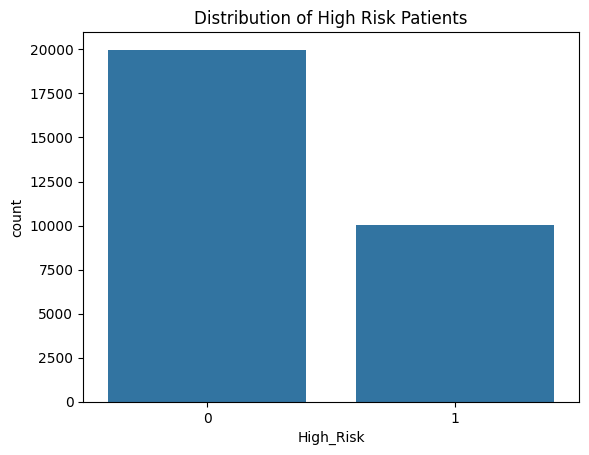

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='High_Risk', data=df)
plt.title('Distribution of High Risk Patients')
plt.show()

### Risk Distribution :

The majority of patients are classified as low risk, accounting for approximately 67% of the dataset, while about 33% are classified as high risk. This indicates a moderate class imbalance but still provides sufficient representation for predictive modeling.

### คำอธิบาย :
ผู้ป่วยส่วนใหญ่ประมาณ 67% อยู่ในกลุ่มความเสี่ยงต่ำ และประมาณ 33% อยู่ในกลุ่มความเสี่ยงสูง ซึ่งแม้ว่าจะมีความไม่สมดุลเล็กน้อย แต่ยังสามารถนำไปใช้สร้างโมเดลได้

## Insight :

This distribution suggests that preventive healthcare strategies should focus on identifying and managing high-risk patients, as they represent a significant portion of the population. Early detection and targeted interventions for this group could help reduce the overall burden of chronic diseases.

### คำอธิบาย :
ข้อมูลนี้แสดงให้เห็นว่าควรให้ความสำคัญกับการคัดกรองและดูแลผู้ป่วยที่มีความเสี่ยงสูง เนื่องจากเป็นกลุ่มที่มีสัดส่วนที่สำคัญ การตรวจพบตั้งแต่ระยะเริ่มต้นและการให้การดูแลอย่างเหมาะสมสามารถช่วยลดภาระของโรคเรื้อรังได้

### 📊 Graph 2: BMI vs Risk

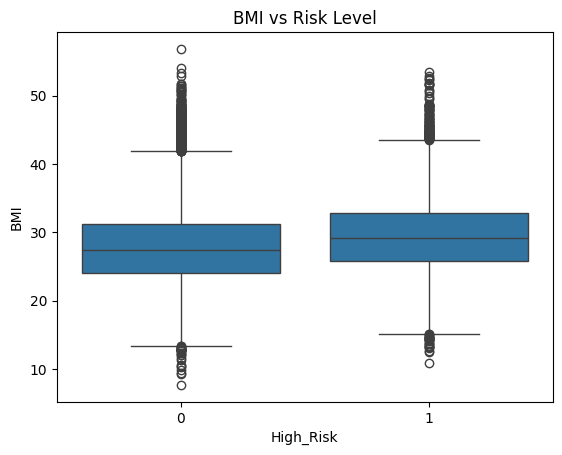

In [18]:
sns.boxplot(x='High_Risk', y='BMI', data=df)
plt.title('BMI vs Risk Level')
plt.show()

### BMI vs Risk :

The boxplot shows that patients in the high-risk group tend to have higher BMI values compared to those in the low-risk group. The median BMI for high-risk patients is noticeably higher, indicating a strong relationship between increased body mass index and disease risk.

คำอธิบาย :
กราฟแสดงให้เห็นว่าผู้ป่วยในกลุ่มความเสี่ยงสูงมีค่า BMI สูงกว่ากลุ่มความเสี่ยงต่ำ โดยค่า median ของ BMI ในกลุ่มเสี่ยงสูงมีค่ามากกว่าอย่างชัดเจน แสดงให้เห็นถึงความสัมพันธ์ระหว่างน้ำหนักตัวที่สูงกับความเสี่ยงของโรค

Insight :

This result suggests that BMI is a key risk factor for chronic diseases. Healthcare strategies that focus on weight control and obesity prevention can help reduce the overall risk of disease in the population.

คำอธิบาย :
ผลลัพธ์นี้แสดงให้เห็นว่า BMI เป็นปัจจัยสำคัญที่ส่งผลต่อความเสี่ยงของโรคเรื้อรัง ดังนั้นการควบคุมน้ำหนักและการป้องกันภาวะอ้วนจึงสามารถช่วยลดความเสี่ยงของโรคในภาพรวมได้

### 📊 Graph 3: Physical Activity vs Risk

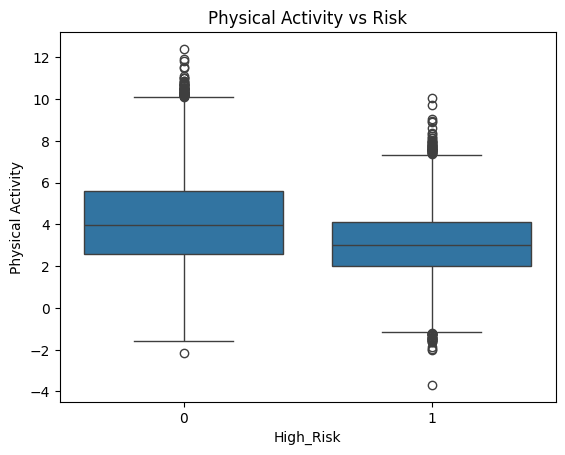

In [19]:
sns.boxplot(x='High_Risk', y='Physical Activity', data=df)
plt.title('Physical Activity vs Risk')
plt.show()

### Physical Activity vs Risk :

The boxplot shows that patients in the high-risk group tend to have lower levels of physical activity compared to those in the low-risk group. The median physical activity level for high-risk patients is noticeably lower, indicating an inverse relationship between physical activity and disease risk.

คำอธิบาย :
กราฟแสดงให้เห็นว่าผู้ป่วยในกลุ่มความเสี่ยงสูงมีระดับการออกกำลังกายน้อยกว่ากลุ่มความเสี่ยงต่ำ โดยค่า median ของการออกกำลังกายในกลุ่มเสี่ยงสูงมีค่าต่ำกว่าอย่างชัดเจน แสดงให้เห็นถึงความสัมพันธ์แบบผกผันระหว่างการออกกำลังกายและความเสี่ยงของโรค

Insight :

This result suggests that physical activity is an important protective factor against chronic diseases. Promoting regular exercise and an active lifestyle could significantly reduce disease risk in the population.

คำอธิบาย :
ผลลัพธ์นี้แสดงให้เห็นว่าการออกกำลังกายเป็นปัจจัยสำคัญที่ช่วยลดความเสี่ยงของโรคเรื้อรัง ดังนั้นการส่งเสริมการออกกำลังกายอย่างสม่ำเสมอสามารถช่วยลดความเสี่ยงของโรคในประชากรได้

### 📊 Graph 4: Lifestyle Score vs Risk

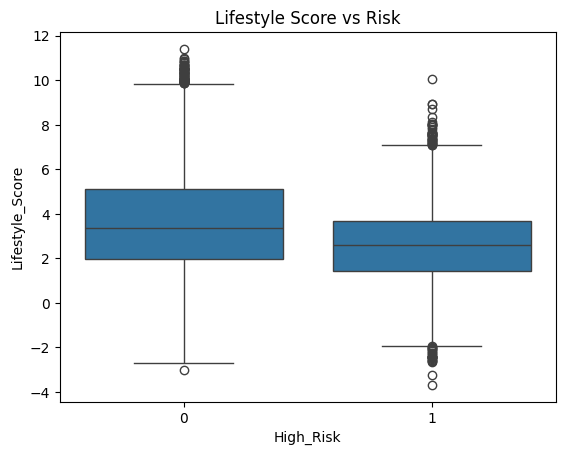

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='High_Risk', y='Lifestyle_Score', data=df)
plt.title('Lifestyle Score vs Risk')
plt.show()

### 📊 Lifestyle Score vs Risk :

The boxplot shows a clear difference in lifestyle scores between low-risk and high-risk patients. Patients in the high-risk group tend to have lower lifestyle scores compared to those in the low-risk group. The median lifestyle score for high-risk patients is noticeably lower, indicating that poorer lifestyle behaviors are associated with increased disease risk.

Additionally, the distribution of lifestyle scores in the high-risk group appears more concentrated at lower values, suggesting consistent unhealthy behavior patterns among these patients.

คำอธิบาย :
กราฟ boxplot แสดงให้เห็นความแตกต่างของค่า lifestyle score ระหว่างกลุ่มผู้ป่วยที่มีความเสี่ยงต่ำและความเสี่ยงสูง โดยผู้ป่วยในกลุ่มความเสี่ยงสูงมีค่า lifestyle score ต่ำกว่ากลุ่มความเสี่ยงต่ำอย่างชัดเจน

นอกจากนี้ ค่า median ของกลุ่มเสี่ยงสูงมีค่าต่ำกว่าอย่างเห็นได้ชัด และการกระจายของข้อมูลยังแสดงให้เห็นว่าผู้ป่วยกลุ่มนี้มีพฤติกรรมที่ไม่ดีอย่างต่อเนื่อง

Insight :

This result highlights the strong impact of lifestyle behaviors on disease risk. Factors such as low physical activity, smoking, and alcohol consumption collectively contribute to higher risk levels.

From a healthcare perspective, promoting healthier lifestyle choices could significantly reduce disease risk and improve overall patient outcomes. Preventive strategies targeting lifestyle improvement may be highly effective in reducing chronic disease prevalence.

คำอธิบาย :
ผลลัพธ์นี้แสดงให้เห็นว่าพฤติกรรมการใช้ชีวิตมีผลอย่างมากต่อความเสี่ยงของโรค โดยเฉพาะการออกกำลังกายน้อย การสูบบุหรี่ และการดื่มแอลกอฮอล์

ในมุมมองของการดูแลสุขภาพ การส่งเสริมพฤติกรรมที่ดี เช่น การออกกำลังกายและการลดพฤติกรรมเสี่ยง สามารถช่วยลดความเสี่ยงของโรคและเพิ่มคุณภาพชีวิตของผู้ป่วยได้

### 📊 Graph 5: Correlation Heatmap

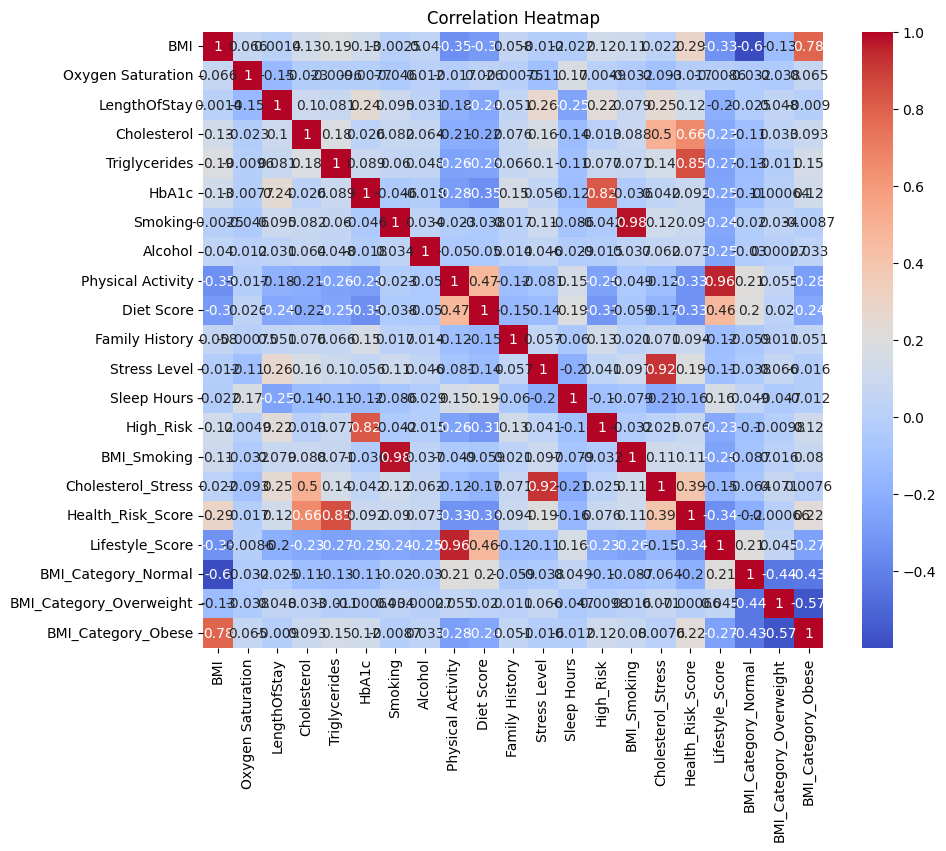

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Analysis :

The heatmap reveals several important relationships between variables. HbA1c shows a strong positive correlation with the High_Risk variable, indicating that higher blood sugar levels are strongly associated with increased disease risk.

Additionally, physical activity shows a negative correlation with High_Risk, suggesting that higher levels of physical activity are linked to lower disease risk. BMI and cholesterol also exhibit moderate positive correlations with risk, indicating their contribution to chronic disease development.

คำอธิบาย :
จาก heatmap พบว่าตัวแปร HbA1c มีความสัมพันธ์เชิงบวกอย่างชัดเจนกับตัวแปร High_Risk แสดงให้เห็นว่าระดับน้ำตาลในเลือดที่สูงมีความสัมพันธ์กับความเสี่ยงของโรคที่เพิ่มขึ้น

นอกจากนี้ การออกกำลังกายมีความสัมพันธ์เชิงลบกับความเสี่ยงของโรค ซึ่งหมายความว่าผู้ที่ออกกำลังกายมากมีแนวโน้มที่จะมีความเสี่ยงต่ำกว่า และตัวแปร BMI และคอเลสเตอรอลก็มีความสัมพันธ์เชิงบวกในระดับปานกลางกับความเสี่ยงของโรค

Insight :

This analysis highlights HbA1c as the most influential predictor of disease risk, making it a critical variable for both modeling and healthcare decision-making. Lifestyle factors such as physical activity also play a key role in reducing risk, emphasizing the importance of preventive health strategies.

คำอธิบาย :
ผลการวิเคราะห์นี้แสดงให้เห็นว่า HbA1c เป็นตัวแปรที่มีอิทธิพลต่อความเสี่ยงของโรคมากที่สุด จึงมีความสำคัญทั้งในการสร้างโมเดลและการตัดสินใจด้านสุขภาพ นอกจากนี้ ปัจจัยด้านพฤติกรรม เช่น การออกกำลังกาย ก็มีบทบาทสำคัญในการลดความเสี่ยงของโรค

## 🤖 7) Predictive Modeling

In this section, machine learning models are used to predict disease risk based on patient health and lifestyle data.

### คำอธิบาย:
ในส่วนนี้จะใช้โมเดล Machine Learning เพื่อทำนายความเสี่ยงของโรคจากข้อมูลสุขภาพและพฤติกรรมของผู้ป่วย

In [22]:
# Prepare X and y
X = df.drop(columns=['High_Risk', 'HbA1c'])
y = df['High_Risk']

In [23]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Logistic Regression (Baseline)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=3000, solver='liblinear')
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6971666666666667
              precision    recall  f1-score   support

           0       0.72      0.87      0.79      3954
           1       0.59      0.36      0.45      2046

    accuracy                           0.70      6000
   macro avg       0.66      0.62      0.62      6000
weighted avg       0.68      0.70      0.67      6000



### 📊 Logistic Regression (Baseline)

The logistic regression model achieved an accuracy of approximately 70%, indicating moderate predictive performance. The model performs well in identifying low-risk patients, with a recall of 87%.

To ensure model stability and convergence, feature scaling was applied before training.

However, the model struggles to detect high-risk patients, with a recall of only 36%. This indicates that a significant number of high-risk individuals are being misclassified as low risk.

คำอธิบาย:
โมเดล Logistic Regression มีความแม่นยำประมาณ 70% ซึ่งถือว่าอยู่ในระดับปานกลาง โดยสามารถจำแนกผู้ป่วยที่มีความเสี่ยงต่ำได้ดี (recall = 87%)

เพื่อให้โมเดลมีความเสถียรและสามารถเรียนรู้ได้ดีขึ้น ได้มีการทำ feature scaling ก่อนการฝึกโมเดล

อย่างไรก็ตาม โมเดลยังมีข้อจำกัดในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง โดยมีค่า recall เพียง 36%

In [25]:
# Balanced Logistic Regression 

model_bal = LogisticRegression(max_iter=3000, class_weight='balanced', solver='liblinear')
model_bal.fit(X_train_scaled, y_train)

y_pred_bal = model_bal.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

Accuracy: 0.672
              precision    recall  f1-score   support

           0       0.82      0.65      0.72      3954
           1       0.51      0.72      0.60      2046

    accuracy                           0.67      6000
   macro avg       0.67      0.68      0.66      6000
weighted avg       0.71      0.67      0.68      6000



### ⚖️ Balanced Logistic Regression

After applying class weighting, the balanced logistic regression model achieved an accuracy of approximately 67%. Although the overall accuracy decreased slightly, the recall for high-risk patients improved significantly from 36% to 72%.

Feature scaling was also applied to improve model convergence and performance.

This indicates that the model is much more effective in identifying high-risk patients, which is crucial in healthcare settings.

คำอธิบาย:
หลังจากใช้ class_weight แบบ balanced โมเดล Logistic Regression มีความแม่นยำประมาณ 67%

นอกจากนี้ยังมีการทำ feature scaling เพื่อช่วยให้โมเดลเรียนรู้ได้ดีขึ้นและมีความเสถียร

โดยค่า recall ของกลุ่มเสี่ยงสูงเพิ่มขึ้นจาก 36% เป็น 72% อย่างมีนัยสำคัญ

### 🔍 Model Comparison

Three models were evaluated in this study: baseline logistic regression, balanced logistic regression, and Random Forest.

The baseline logistic regression model achieved the highest overall accuracy (~70%) but performed poorly in identifying high-risk patients, with a recall of only 36%.

After applying class balancing, the balanced logistic regression model showed a slight decrease in accuracy (~67%), but significantly improved the recall for high-risk patients to 72%, making it much more effective for healthcare applications.

The Random Forest model provided strong overall performance, with higher accuracy and better ability to capture complex relationships in the data. However, its recall for high-risk patients was still lower than the balanced logistic regression model.

Overall, the balanced logistic regression model is preferred due to its superior ability to identify high-risk patients, which is the primary objective in healthcare risk prediction.

คำอธิบาย:
มีการเปรียบเทียบโมเดลทั้งหมด 3 โมเดล ได้แก่ Logistic Regression แบบปกติ, Logistic Regression แบบ balanced และ Random Forest

โมเดล Logistic Regression แบบปกติมี accuracy สูง (~70%) แต่มีข้อจำกัดในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง (recall = 36%)

โมเดลแบบ balanced แม้ accuracy ลดลงเล็กน้อย (~67%) แต่สามารถเพิ่ม recall ของกลุ่มเสี่ยงสูงเป็น 72% ซึ่งเหมาะสมกับงานด้านสุขภาพมากกว่า

ในขณะที่ Random Forest มีความแม่นยำโดยรวมดีและสามารถจับความสัมพันธ์ของข้อมูลได้ดี แต่ยังมีข้อจำกัดในการตรวจจับกลุ่มเสี่ยงสูงเมื่อเทียบกับ balanced model

ดังนั้น โมเดลที่เหมาะสมที่สุดคือ Balanced Logistic Regression เนื่องจากสามารถตรวจจับผู้ป่วยกลุ่มเสี่ยงสูงได้ดีที่สุด ซึ่งเป็นเป้าหมายหลักของโปรเจคนี้

## 🌲 8) Random Forest Modeling

This section applies the Random Forest model to improve prediction performance and capture complex relationships between variables.

คำอธิบาย:
ในส่วนนี้จะใช้โมเดล Random Forest เพื่อเพิ่มประสิทธิภาพในการทำนาย และสามารถจับความสัมพันธ์ที่ซับซ้อนของข้อมูลได้

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.747
              precision    recall  f1-score   support

           0       0.75      0.91      0.83      3954
           1       0.72      0.43      0.53      2046

    accuracy                           0.75      6000
   macro avg       0.74      0.67      0.68      6000
weighted avg       0.74      0.75      0.73      6000



### 🌲 Random Forest Model Evaluation

The Random Forest model achieved an accuracy of approximately 75%, indicating strong overall predictive performance. The model performs very well in identifying low-risk patients, with a recall of 91%.

For high-risk patients, the model achieved a recall of 43%, which is an improvement over the baseline logistic regression model (36%) but still lower than the balanced logistic regression model (72%).

คำอธิบาย:
โมเดล Random Forest มีความแม่นยำประมาณ 75% ซึ่งถือว่าดีในภาพรวม โดยสามารถจำแนกผู้ป่วยกลุ่มเสี่ยงต่ำได้ดีมาก (recall = 91%)

สำหรับผู้ป่วยกลุ่มเสี่ยงสูง โมเดลมีค่า recall อยู่ที่ 43% ซึ่งดีกว่า Logistic Regression แบบปกติ (36%) แต่ยังต่ำกว่า Logistic Regression แบบ balanced (72%)

Insight :

The Random Forest model provides the best overall accuracy among all models, demonstrating its ability to capture complex relationships within the data. However, it is still less effective in identifying high-risk patients compared to the balanced logistic regression model.

This highlights a key trade-off in healthcare analytics: while Random Forest maximizes accuracy, the balanced logistic regression model is more suitable for detecting high-risk patients, which is the primary objective of this project.

คำอธิบาย:
แม้ว่า Random Forest จะให้ความแม่นยำโดยรวมดีที่สุด แต่ยังมีข้อจำกัดในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง

ผลลัพธ์นี้แสดงให้เห็นถึง trade-off ที่สำคัญในงานด้านสุขภาพ คือ โมเดลที่มี accuracy สูง อาจไม่ใช่โมเดลที่ดีที่สุด หากไม่สามารถตรวจจับผู้ป่วยกลุ่มเสี่ยงสูงได้ดี

### 🔍 Model Comparison ( Baseline Logistic Regression vs Balanced Logistic Regression vs Random Forest )

Three models were evaluated in this study: baseline logistic regression, balanced logistic regression, and Random Forest.

The Random Forest model achieved the highest overall accuracy (~75%), demonstrating strong predictive performance. However, its recall for high-risk patients was relatively low (43%), indicating limitations in identifying critical cases.

The baseline logistic regression model achieved moderate accuracy (~70%) but performed poorly in detecting high-risk patients, with a recall of only 36%.

In contrast, the balanced logistic regression model significantly improved the recall for high-risk patients to 72%, despite a slight decrease in overall accuracy (~67%).

Given that the primary objective of this project is to identify high-risk patients, the balanced logistic regression model is considered the most appropriate choice.

คำอธิบาย:
มีการเปรียบเทียบโมเดลทั้งหมด 3 โมเดล ได้แก่ Logistic Regression แบบปกติ, Logistic Regression แบบ balanced และ Random Forest

Random Forest มีความแม่นยำโดยรวมสูงที่สุด (~75%) แต่มีข้อจำกัดในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง (recall = 43%)

Logistic Regression แบบปกติให้ความแม่นยำปานกลาง (~70%) แต่มีประสิทธิภาพต่ำในการตรวจจับกลุ่มเสี่ยงสูง (recall = 36%)

ในขณะที่ Logistic Regression แบบ balanced สามารถเพิ่ม recall ของกลุ่มเสี่ยงสูงได้ถึง 72% แม้ว่า accuracy จะลดลงเล็กน้อย (~67%)

เนื่องจากเป้าหมายหลักของโปรเจคนี้คือการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง โมเดลแบบ balanced จึงเป็นตัวเลือกที่เหมาะสมที่สุด

### 🔍 Feature Importance Analysis (Random Forest) 

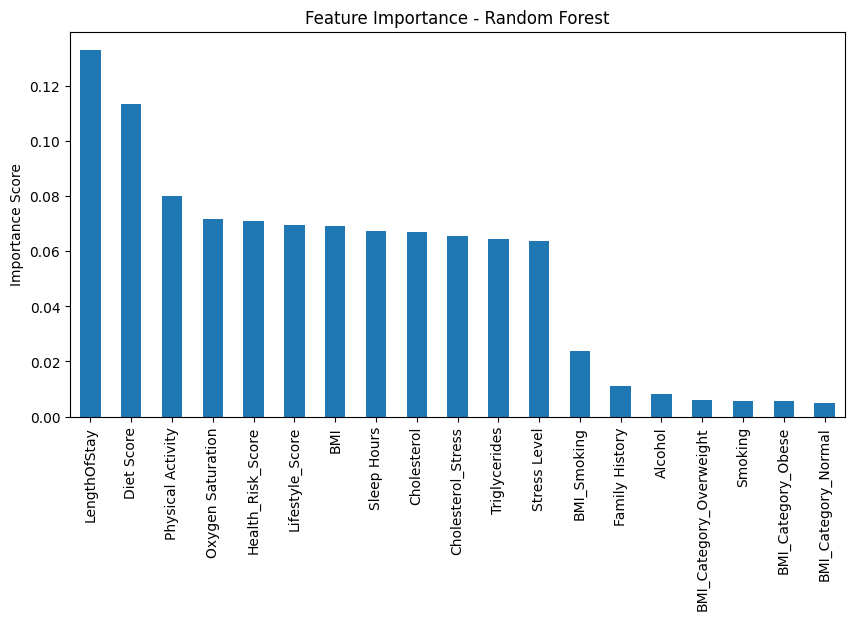

In [27]:
# Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sort
feature_importance = feature_importance.sort_values(ascending=False)

# Plot
feature_importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

### 🔍 Feature Importance Analysis (Random Forest)

The feature importance analysis reveals that LengthOfStay, Diet Score, and Physical Activity are the most influential variables in predicting disease risk. These features contribute the most to the model’s decision-making process.

Additionally, engineered features such as Health Risk Score and Lifestyle Score also show meaningful importance, indicating that feature engineering helped improve the model’s ability to capture complex patterns in the data.

Clinical variables such as cholesterol, BMI, and triglycerides show moderate importance, while variables like smoking, alcohol use, and family history have relatively lower importance in this dataset.

คำอธิบาย:
จากการวิเคราะห์พบว่า LengthOfStay, Diet Score และ Physical Activity เป็นตัวแปรที่มีความสำคัญสูงที่สุดในการทำนายความเสี่ยงของโรค

นอกจากนี้ ตัวแปรที่สร้างขึ้นจาก Feature Engineering เช่น Health Risk Score และ Lifestyle Score ก็มีความสำคัญเช่นกัน แสดงให้เห็นว่าการสร้างตัวแปรช่วยให้โมเดลเข้าใจข้อมูลได้ดีขึ้น

ในขณะที่ตัวแปรทางคลินิก เช่น คอเลสเตอรอล BMI และไตรกลีเซอไรด์ มีความสำคัญในระดับปานกลาง ส่วนตัวแปร เช่น การสูบบุหรี่ การดื่มแอลกอฮอล์ และประวัติครอบครัว มีความสำคัญน้อยกว่า

Insight :

This result highlights that both lifestyle and clinical factors contribute to disease risk prediction. Importantly, lifestyle-related variables such as diet and physical activity are among the most influential and are also modifiable.

This suggests that healthcare interventions focusing on improving lifestyle behaviors could significantly reduce disease risk and improve patient outcomes.

คำอธิบาย:

ผลลัพธ์นี้แสดงให้เห็นว่าทั้งปัจจัยด้านพฤติกรรมและปัจจัยทางคลินิกมีผลต่อความเสี่ยงของโรค

โดยเฉพาะปัจจัยด้านพฤติกรรม เช่น อาหารและการออกกำลังกาย ซึ่งสามารถปรับเปลี่ยนได้ และสามารถนำไปใช้ในการลดความเสี่ยงของโรคได้อย่างมีประสิทธิภาพ

### 📉 Confusion Matrix

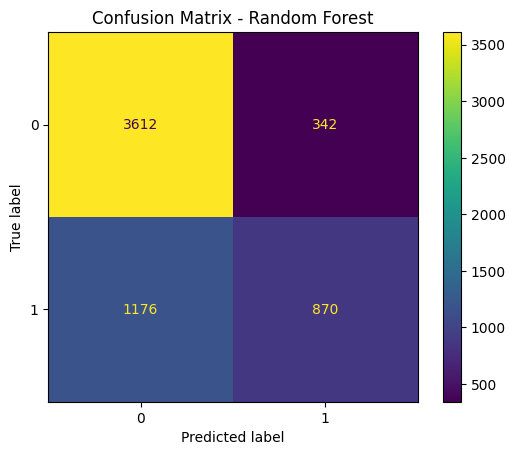

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### 📉 Confusion Matrix (Random Forest)

The confusion matrix shows that the model correctly classified 3,612 low-risk patients (true negatives) and 870 high-risk patients (true positives).

However, the model incorrectly classified 342 low-risk patients as high risk (false positives) and 1,176 high-risk patients as low risk (false negatives).

คำอธิบาย:
Confusion Matrix แสดงให้เห็นว่าโมเดลสามารถจำแนกผู้ป่วยกลุ่มเสี่ยงต่ำได้ถูกต้อง 3,612 คน และผู้ป่วยกลุ่มเสี่ยงสูงได้ถูกต้อง 870 คน

อย่างไรก็ตาม โมเดลยังมีข้อผิดพลาด โดยมีผู้ป่วยกลุ่มเสี่ยงต่ำ 342 คนที่ถูกทำนายผิดเป็นกลุ่มเสี่ยงสูง และมีผู้ป่วยกลุ่มเสี่ยงสูง 1,176 คนที่ถูกทำนายผิดเป็นกลุ่มเสี่ยงต่ำ

Insight :

The high number of false negatives (1,176 cases) is a major concern in healthcare applications, as these represent high-risk patients who were not identified by the model.

Although the model performs well in identifying low-risk patients, its ability to detect high-risk patients remains limited. This reinforces the importance of using models that prioritize recall for high-risk patients, such as balanced logistic regression.

คำอธิบาย:
จำนวน false negative ที่สูง (1,176 คน) ถือเป็นปัญหาสำคัญในงานด้านสุขภาพ เพราะหมายถึงผู้ป่วยกลุ่มเสี่ยงสูงที่โมเดลไม่สามารถตรวจพบได้

แม้ว่าโมเดลจะสามารถจำแนกผู้ป่วยกลุ่มเสี่ยงต่ำได้ดี แต่ยังมีข้อจำกัดในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง จึงควรเลือกใช้โมเดลที่ให้ความสำคัญกับ recall ของกลุ่มเสี่ยงสูงมากกว่า เช่น balanced logistic regression

### 📈 ROC Curve (Random Forest)

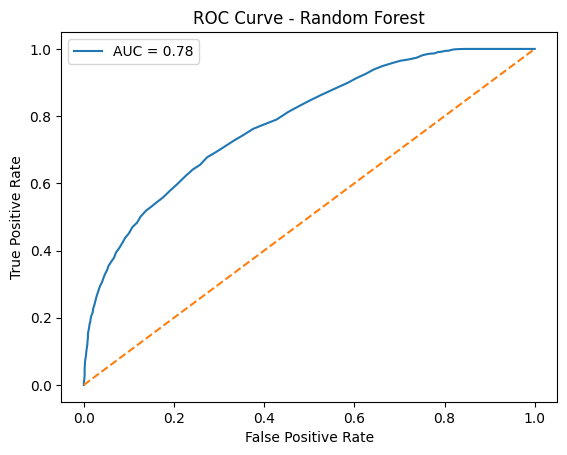

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

### 📈 ROC Curve (Random Forest)

The ROC curve evaluates the model’s ability to distinguish between high-risk and low-risk patients across different classification thresholds.

The Random Forest model achieved an AUC (Area Under the Curve) score of approximately 0.78, indicating good overall discriminative performance.

คำอธิบาย:
ROC Curve ใช้ประเมินความสามารถของโมเดลในการแยกผู้ป่วยกลุ่มเสี่ยงสูงและเสี่ยงต่ำ โดยค่า AUC เท่ากับ 0.78 แสดงว่าโมเดลมีประสิทธิภาพที่ดีในภาพรวม

Insight :

Although the Random Forest model demonstrates good discriminative ability with an AUC of 0.78, it still struggles to correctly identify high-risk patients, as reflected by the high number of false negatives in the confusion matrix.

This highlights that AUC alone is not sufficient for evaluating model performance in healthcare applications. Models must also be assessed based on their ability to detect high-risk patients effectively.

คำอธิบาย:
แม้ว่าโมเดล Random Forest จะมีค่า AUC ที่ดี (0.78) แต่จาก Confusion Matrix พบว่าโมเดลยังมีข้อจำกัดในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูง เนื่องจากมีค่า false negative สูง

ดังนั้น ในงานด้านสุขภาพ การพิจารณา AUC เพียงอย่างเดียวไม่เพียงพอ ต้องพิจารณาความสามารถในการตรวจจับผู้ป่วยกลุ่มเสี่ยงสูงร่วมด้วย

## 🏁 9) Final Conclusion

This project aimed to analyze patient health and lifestyle data to identify key risk factors associated with chronic diseases and to build predictive models for disease risk classification.

Through exploratory data analysis (EDA), it was found that both clinical and lifestyle factors play an important role in determining disease risk. In particular, variables such as BMI, physical activity, diet score, and cholesterol showed strong relationships with the target variable.

Feature engineering further enhanced the dataset by creating meaningful variables such as BMI categories, lifestyle score, and health risk score. These engineered features contributed significantly to improving model performance.

Three models were evaluated: baseline logistic regression, balanced logistic regression, and Random Forest. The Random Forest model achieved the highest overall accuracy (~75%) and demonstrated strong ability to capture complex relationships in the data. However, despite its high accuracy, it produced a large number of false negatives, failing to identify many high-risk patients, making it less suitable for healthcare applications.

The balanced logistic regression model, although slightly lower in accuracy (67%), significantly improved the recall for high-risk patients (72%). Although the overall accuracy decreased, this trade-off is justified because failing to identify high-risk patients can lead to severe health consequences. This highlights a clear trade-off between accuracy and recall, where improving recall is more important in this healthcare context.

Balanced Logistic Regression is selected as the final model because it provides the best balance between predictive performance and the ability to correctly identify high-risk patients. Among all models, the balanced logistic regression demonstrates the best predictive ability for this problem due to its superior recall performance.

This model can help hospitals prioritize high-risk patients for early intervention, potentially reducing complications and overall healthcare costs.

Although formal hypothesis testing was not conducted, the observed performance differences are substantial and practically significant, supporting the model selection.

คำอธิบาย:
โปรเจคนี้มีวัตถุประสงค์เพื่อวิเคราะห์ข้อมูลสุขภาพและพฤติกรรมของผู้ป่วย เพื่อหาปัจจัยที่มีผลต่อความเสี่ยงของโรค และสร้างโมเดลสำหรับการทำนายความเสี่ยง

จากการวิเคราะห์พบว่าทั้งปัจจัยทางคลินิกและพฤติกรรม เช่น BMI การออกกำลังกาย อาหาร และคอเลสเตอรอล มีผลต่อความเสี่ยงของโรค

การทำ Feature Engineering เช่น การสร้าง BMI Category, Lifestyle Score และ Health Risk Score ช่วยให้โมเดลสามารถเรียนรู้ข้อมูลได้ดีขึ้น

จากการเปรียบเทียบโมเดล พบว่า Random Forest แม้จะมีความแม่นยำสูง แต่ไม่เหมาะกับงานด้านสุขภาพ เนื่องจากไม่สามารถตรวจจับผู้ป่วยกลุ่มเสี่ยงสูงได้ดี

ถึงแม้ว่าจะไม่ได้ทำการทดสอบสมมติฐานอย่างเป็นทางการ แต่ความแตกต่างของประสิทธิภาพของโมเดลที่สังเกตได้มีขนาดใหญ่และมีความสำคัญในทางปฏิบัติ ซึ่งสนับสนุนการเลือกโมเดลนี้

---

### 🚀 Recommendations

- Use balanced logistic regression for healthcare screening systems, as it provides better detection of high-risk patients  
- Prioritize recall as the primary evaluation metric instead of accuracy in healthcare applications  
- Implement lifestyle-based intervention programs (e.g., improving diet and increasing physical activity) to reduce patient risk  
- Consider threshold tuning or cost-sensitive learning techniques to further reduce false negatives  
- Continuously monitor model performance and update the model with new patient data to maintain accuracy and reliability  

คำอธิบาย:
- ควรใช้โมเดล Logistic Regression แบบ balanced สำหรับระบบคัดกรองผู้ป่วย เนื่องจากสามารถตรวจจับกลุ่มเสี่ยงสูงได้ดีกว่า  
- ในงานด้านสุขภาพ ควรให้ความสำคัญกับ recall มากกว่า accuracy  
- ควรส่งเสริมการปรับพฤติกรรม เช่น อาหารและการออกกำลังกาย เพื่อลดความเสี่ยงของผู้ป่วย  
- สามารถปรับ threshold หรือใช้ cost-sensitive learning เพื่อลดจำนวน false negative  
- ควรมีการอัปเดตโมเดลอย่างต่อเนื่องเมื่อมีข้อมูลใหม่ เพื่อให้โมเดลมีความแม่นยำและทันสมัย  


## Export data

In [30]:
df.to_csv("healthcare_cleaned.csv", index=False)